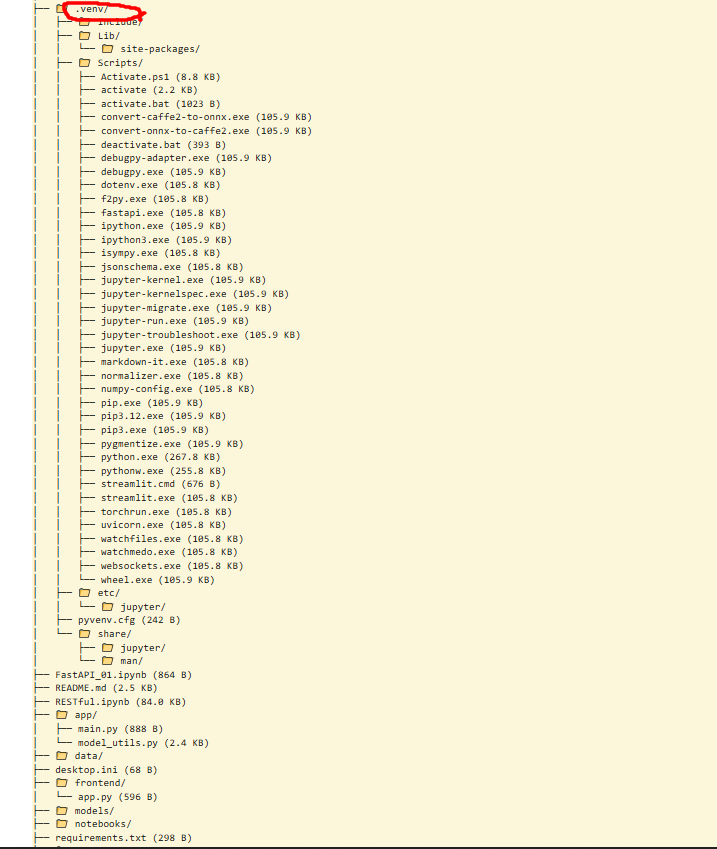

### step 1 작업폴더 확인 및 이동 

In [1]:
# ============================================================
# [STEP 0] 작업 폴더 확인
# - 이 노트북은 로컬 Jupyter Notebook에서 실행
# - 목표 작업 폴더:
#   D:\PyProject\AIFFEL_AI\LLM\MLOps\MLOps01
# ============================================================

import os
from pathlib import Path

PROJECT_DIR = Path(r"D:\PyProject\AIFFEL_AI\LLM\MLOps\MLOps01")

# 폴더가 없으면 생성
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

# 작업 폴더로 이동
os.chdir(PROJECT_DIR)

print("현재 작업 폴더:", os.getcwd())
print("폴더 존재 여부:", PROJECT_DIR.exists())

현재 작업 폴더: D:\PyProject\AIFFEL_AI\LLM\MLOps\MLOps01
폴더 존재 여부: True


In [3]:
# ============================================================
# [STEP 1] 현재 Jupyter 커널의 Python 확인
# - 현재 어떤 파이썬으로 노트북이 실행 중인지' 확인
# ============================================================

import sys

print("현재 Python 실행 경로:")
print(sys.executable)

현재 Python 실행 경로:
D:\anaconda3\envs\aiffel\python.exe


### step 2 conda AIFEEL과 다른 새 가상환경(새로운 폴더) 생성

In [5]:
# ============================================================
# [STEP 2] 새 Python 가상환경 생성
# - 첨부 파일 흐름대로 .venv를 프로젝트 내부에 만듦
# - 현재 Jupyter 커널의 Python으로 .venv를 생성합니다.
# ============================================================

import sys
import subprocess
from pathlib import Path

venv_dir = Path(".venv")

if venv_dir.exists():
    print("이미 .venv가 존재합니다.")
else:
    print(".venv 생성 시작...")
    subprocess.run([sys.executable, "-m", "venv", ".venv"], check=True)
    print(".venv 생성 완료")

print("가상환경 폴더 존재 여부:", venv_dir.exists())

.venv 생성 시작...
.venv 생성 완료
가상환경 폴더 존재 여부: True


In [9]:
# ============================================================
# [STEP 3] .venv 생성 확인
# - Windows에서는 Scripts 폴더가 보여야 정상임
# ============================================================

from pathlib import Path
import os

venv_path = Path(".venv")
print("exists:", venv_path.exists())

if venv_path.exists():
    print("상위 항목 일부:")
    print(sorted(os.listdir(venv_path))[:20])

exists: True
상위 항목 일부:
['Include', 'Lib', 'Scripts', 'pyvenv.cfg']


In [11]:
# ============================================================
# [STEP 4] .venv를 Jupyter 커널로 등록
# - 이 단계가 중요합니다.
# - 이 노트북(RESTful.ipynb)을 새 가상환경으로 실행하게 만들어 줍니다.
# ============================================================

import subprocess
from pathlib import Path

venv_python = Path(".venv") / "Scripts" / "python.exe"

# 1) pip, setuptools, wheel, ipykernel 설치/업그레이드
subprocess.run(
    [str(venv_python), "-m", "pip", "install", "--upgrade", "pip", "setuptools", "wheel", "ipykernel"],
    check=True
)

# 2) Jupyter 커널 등록
subprocess.run(
    [
        str(venv_python),
        "-m",
        "ipykernel",
        "install",
        "--user",
        "--name=mlops01-restful",
        "--display-name=MLOps01 RESTful (.venv)"
    ],
    check=True
)

print("커널 등록 완료")
print("이제 Jupyter 상단 메뉴에서:")
print("Kernel -> Change Kernel -> 'MLOps01 RESTful (.venv)' 로 바꾸세요.")

커널 등록 완료
이제 Jupyter 상단 메뉴에서:
Kernel -> Change Kernel -> 'MLOps01 RESTful (.venv)' 로 바꾸세요.


In [3]:
# ============================================================
# [STEP 5] 커널 전환 후 확인
# - 반드시 'MLOps01 RESTful (.venv)' 커널로 바꾼 다음 실행
# ============================================================

import sys

print("현재 Python 경로:")
print(sys.executable)

print("\n아래 경로에 .venv\\Scripts\\python.exe 가 포함되면 성공입니다.")

현재 Python 경로:
D:\PyProject\AIFFEL_AI\LLM\MLOps\MLOps01\.venv\Scripts\python.exe

아래 경로에 .venv\Scripts\python.exe 가 포함되면 성공입니다.


### requirements.txt 작성 및 설치

In [5]:
# ============================================================
# [STEP 6] requirements.txt 작성
# - 첨부 파일의 핵심 패키지 구성을 반영합니다.
# ============================================================

requirements_text = """# ===== Core =====
torch>=2.1.0,<2.5.0
torchvision>=0.16.0,<0.20.0

# ===== API =====
fastapi==0.115.0
uvicorn[standard]==0.30.0
pydantic>=2.0.0,<3.0.0

# ===== Frontend =====
streamlit==1.38.0

# ===== Utilities =====
requests>=2.31.0,<3.0.0
pillow>=10.0.0
python-multipart>=0.0.6
"""

with open("requirements.txt", "w", encoding="utf-8") as f:
    f.write(requirements_text)

print("requirements.txt 작성 완료")
print("-" * 60)
print(requirements_text)

requirements.txt 작성 완료
------------------------------------------------------------
# ===== Core =====
torch>=2.1.0,<2.5.0
torchvision>=0.16.0,<0.20.0

# ===== API =====
fastapi==0.115.0
uvicorn[standard]==0.30.0
pydantic>=2.0.0,<3.0.0

# ===== Frontend =====
streamlit==1.38.0

# ===== Utilities =====
requests>=2.31.0,<3.0.0
pillow>=10.0.0
python-multipart>=0.0.6



In [7]:
# ============================================================
# [STEP 7] requirements.txt 설치
# - 현재 노트북 커널(.venv) 기준으로 설치
# ============================================================

%pip install -r requirements.txt

  Using cached pydantic-2.12.5-py3-none-any.whl.metadata (90 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached click-8.3.1-py3-none-any.whl.metadata (2.6 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached packaging-24.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached protobuf-5.29.6-cp310-abi3-win_amd64.whl.metadata (592 bytes)
  Using cached pyarrow-23.0.1-cp312-cp312-win_amd64.whl.metadata (3.1 kB)
  Using cached tenacity-8.5.0-py3-none-any.whl.metadata (1.2 kB)
  Using cached httptools-0.7.1-cp312-cp312-win_amd64.whl.metadata (3.6 kB)
  Using cached python_dotenv-1.2.2-py3-none-any.whl.metadata (27 kB)
  Using cached pyyaml-6.0.3-cp312-cp312-win_amd64.whl.metadata (2.4 kB)
  Using cached watchfiles-1.1.1-cp312-cp312-win_amd64.whl.metadata (5.0 kB)
  Using cached websockets-16.0-cp312-cp312-win_amd64.whl.metadata (7.0 kB)
  Using cached filelock-3.25.2-py3-none-any.whl.metadata (2.0 kB)
  Using cached annotate

In [8]:
# ============================================================
# [STEP 8] 설치 확인
# ============================================================

import torch
import fastapi
import streamlit
import pydantic
import uvicorn

print(f"PyTorch:   {torch.__version__}")
print(f"FastAPI:   {fastapi.__version__}")
print(f"Streamlit: {streamlit.__version__}")
print(f"Pydantic:  {pydantic.__version__}")
print(f"Uvicorn:   {uvicorn.__version__}")

PyTorch:   2.4.1+cpu
FastAPI:   0.115.0
Streamlit: 1.38.0
Pydantic:  2.12.5
Uvicorn:   0.30.0


### step 3 프로젝트 구조 생성

In [13]:
# ============================================================
# [STEP 9] 프로젝트 폴더 구조 생성
# - 첨부 파일 구조를 현재 MLOps01 폴더 안에 만듭니다.
# ============================================================

import os

folders = [
    "models",      # 저장된 모델 파일
    "app",         # FastAPI 백엔드 코드
    "frontend",    # Streamlit 프론트엔드 코드
    "notebooks",   # 노트북 보관용
    "data",        # 샘플 데이터
    "tests",       # 테스트 코드
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)
    print(f"✅ {folder}/ 생성 완료")

✅ models/ 생성 완료
✅ app/ 생성 완료
✅ frontend/ 생성 완료
✅ notebooks/ 생성 완료
✅ data/ 생성 완료
✅ tests/ 생성 완료


### step 4 .gitignore 작성

In [17]:
# ============================================================
# [STEP 10] .gitignore 작성
# - 첨부 파일 취지 그대로, 가상환경/캐시/모델 파일 등을 제외합니다.
# ============================================================

gitignore_text = """# 가상환경
.venv/

# Python 캐시
__pycache__/
*.pyc
*.pyo

# 모델 파일
models/*.pth
models/*.onnx
models/*.pt

# 주피터 체크포인트
.ipynb_checkpoints/

# OS 파일
.DS_Store
Thumbs.db
"""

with open(".gitignore", "w", encoding="utf-8") as f:
    f.write(gitignore_text)

print(".gitignore 작성 완료")
print("-" * 60)
print(gitignore_text)

.gitignore 작성 완료
------------------------------------------------------------
# 가상환경
.venv/

# Python 캐시
__pycache__/
*.pyc
*.pyo

# 모델 파일
models/*.pth
models/*.onnx
models/*.pt

# 주피터 체크포인트
.ipynb_checkpoints/

# OS 파일
.DS_Store
Thumbs.db



### step 5. app/model_utils.py 작성
- 예제에 나오는 app/model_utils.py 예시를 실제로 파일로 생성 가능하도록 정리
- 아직 모델 파일이 없어도 구조 공부용으로 활용

In [20]:
# ============================================================
# [STEP 11] app/model_utils.py 작성
# - 첨부 파일의 model_utils 예시를 실제 파일로 저장합니다.
# - 아직 모델이 없어도 구조 공부용으로 매우 중요합니다.
# ============================================================

model_utils_code = r'''"""
모델 로드 및 추론 유틸리티
FastAPI 엔드포인트가 이 모듈을 import하여 사용합니다.
"""

import torch
import torch.nn as nn
from torchvision import transforms


# ===== 모델 정의 =====
class SimpleClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# ===== 전처리 =====
preprocess = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])


# ===== 클래스 이름 =====
CLASS_NAMES = [str(i) for i in range(10)]


# ===== 모델 로드 =====
def load_model(model_path: str, num_classes: int = 10) -> nn.Module:
    model = SimpleClassifier(num_classes=num_classes)
    state_dict = torch.load(model_path, map_location="cpu")
    model.load_state_dict(state_dict)
    model.eval()
    return model


# ===== 추론 =====
def predict(model: nn.Module, image_tensor: torch.Tensor) -> dict:
    """
    Args:
        model: 로드된 모델
        image_tensor: (1, 1, 28, 28) 형태의 텐서

    Returns:
        dict:
            {
                "predicted_class": "7",
                "confidence": 0.98,
                "probabilities": {"0": 0.001, ...}
            }
    """
    with torch.no_grad():
        logits = model(image_tensor)
        probs = torch.softmax(logits, dim=1)[0]

    pred_idx = int(torch.argmax(probs).item())
    pred_class = CLASS_NAMES[pred_idx]
    confidence = float(probs[pred_idx].item())

    prob_dict = {
        CLASS_NAMES[i]: float(probs[i].item())
        for i in range(len(CLASS_NAMES))
    }

    return {
        "predicted_class": pred_class,
        "confidence": confidence,
        "probabilities": prob_dict,
    }
'''

with open(r"app\model_utils.py", "w", encoding="utf-8") as f:
    f.write(model_utils_code)

print("app/model_utils.py 작성 완료")

app/model_utils.py 작성 완료


### step 6 app/main.py 작성
- app/main.py 작성

In [23]:
# ============================================================
# [STEP 12] app/main.py 작성
# - RESTful API 공부용 최소 FastAPI 앱 파일입니다.
# - 로컬 localhost 실습용입니다.
# ============================================================

main_code = r'''from fastapi import FastAPI
from pydantic import BaseModel

app = FastAPI(title="MLOps01 RESTful API")


class PredictRequest(BaseModel):
    text: str


class PredictResponse(BaseModel):
    label: str
    confidence: float


@app.get("/")
def root():
    return {"message": "RESTful API is working"}


@app.get("/health")
def health():
    return {"status": "ok"}


@app.post("/predict", response_model=PredictResponse)
def predict(request: PredictRequest):
    # 현재는 공부용 더미 로직
    text = request.text.strip()

    if not text:
        return PredictResponse(label="empty", confidence=0.0)

    # 아주 단순한 예시 분기
    if "좋" in text or "행복" in text or "만족" in text:
        return PredictResponse(label="긍정", confidence=0.92)
    else:
        return PredictResponse(label="부정", confidence=0.78)
'''

with open(r"app\main.py", "w", encoding="utf-8") as f:
    f.write(main_code)

print("app/main.py 작성 완료")

app/main.py 작성 완료


### step 7 frontend/app.py 작성

In [27]:
# ============================================================
# [STEP 13] frontend/app.py 작성
# - Streamlit 최소 프론트엔드 예시
# - FastAPI 서버와 연결하는 구조를 공부하기 좋습니다.
# ============================================================

frontend_code = r'''import requests
import streamlit as st

st.set_page_config(page_title="MLOps01 Frontend", layout="centered")
st.title("MLOps01 RESTful Demo")

api_url = st.text_input("FastAPI URL", value="http://127.0.0.1:8000/predict")
user_text = st.text_input("입력 문장", value="오늘 기분이 좋습니다")

if st.button("예측 요청"):
    try:
        response = requests.post(api_url, json={"text": user_text}, timeout=10)
        st.write("상태코드:", response.status_code)
        st.json(response.json())
    except Exception as e:
        st.error(f"요청 실패: {e}")
'''

with open(r"frontend\app.py", "w", encoding="utf-8") as f:
    f.write(frontend_code)

print("frontend/app.py 작성 완료")

frontend/app.py 작성 완료


### Step 8 트리 구조 확인

In [30]:
# ============================================================
# [STEP 14] 프로젝트 트리 확인
# ============================================================

import os

def show_tree(path, prefix="", max_depth=2, current_depth=0):
    if current_depth >= max_depth:
        return

    entries = sorted(os.listdir(path))
    entries = [e for e in entries if e not in {".venv", "__pycache__", ".ipynb_checkpoints"}]

    for i, entry in enumerate(entries):
        full_path = os.path.join(path, entry)
        connector = "└── " if i == len(entries) - 1 else "├── "

        if os.path.isdir(full_path):
            print(f"{prefix}{connector}📁 {entry}/")
            extension = "    " if i == len(entries) - 1 else "│   "
            show_tree(full_path, prefix + extension, max_depth, current_depth + 1)
        else:
            size = os.path.getsize(full_path)
            size_str = f"({size} B)" if size <= 1024 else f"({size/1024:.1f} KB)"
            print(f"{prefix}{connector}{entry} {size_str}")

print("MLOps01/")
show_tree(".")

MLOps01/
├── .gitignore (221 B)
├── FastAPI_01.ipynb (864 B)
├── README.md (2.5 KB)
├── RESTful.ipynb (81.6 KB)
├── 📁 app/
│   ├── main.py (888 B)
│   └── model_utils.py (2.4 KB)
├── 📁 data/
├── desktop.ini (68 B)
├── 📁 frontend/
│   └── app.py (596 B)
├── 📁 models/
├── 📁 notebooks/
├── requirements.txt (298 B)
├── 📁 tests/
├── 모델배포개론01.ipynb (14984.7 KB)
└── 모델배포개론02.ipynb (11932.9 KB)


In [32]:
# ============================================================
# [STEP] 프로젝트 트리 출력 (캡처 제출용)
# - .venv(.env) 포함
# - 파일 크기 표시
# - depth 조절 가능
# ============================================================

import os

def format_size(size):
    if size < 1024:
        return f"({size} B)"
    elif size < 1024 * 1024:
        return f"({size/1024:.1f} KB)"
    else:
        return f"({size/1024/1024:.1f} MB)"


def show_tree(path, prefix="", max_depth=3, current_depth=0):
    if current_depth > max_depth:
        return

    entries = sorted(os.listdir(path))

    for i, entry in enumerate(entries):
        full_path = os.path.join(path, entry)
        connector = "└── " if i == len(entries) - 1 else "├── "

        if os.path.isdir(full_path):
            print(f"{prefix}{connector}📁 {entry}/")
            extension = "    " if i == len(entries) - 1 else "│   "
            show_tree(full_path, prefix + extension, max_depth, current_depth + 1)
        else:
            size = os.path.getsize(full_path)
            print(f"{prefix}{connector}{entry} {format_size(size)}")


# 실행
print("model-serving-course/")
show_tree(".", max_depth=2)

model-serving-course/
├── .gitignore (221 B)
├── 📁 .ipynb_checkpoints/
│   ├── FastAPI_01-checkpoint.ipynb (72 B)
│   ├── RESTful-checkpoint.ipynb (2.1 MB)
│   ├── 모델배포개론01-checkpoint.ipynb (14.6 MB)
│   └── 모델배포개론02-checkpoint.ipynb (11.7 MB)
├── 📁 .venv/
│   ├── 📁 Include/
│   ├── 📁 Lib/
│   │   └── 📁 site-packages/
│   ├── 📁 Scripts/
│   │   ├── Activate.ps1 (8.8 KB)
│   │   ├── activate (2.2 KB)
│   │   ├── activate.bat (1023 B)
│   │   ├── convert-caffe2-to-onnx.exe (105.9 KB)
│   │   ├── convert-onnx-to-caffe2.exe (105.9 KB)
│   │   ├── deactivate.bat (393 B)
│   │   ├── debugpy-adapter.exe (105.9 KB)
│   │   ├── debugpy.exe (105.9 KB)
│   │   ├── dotenv.exe (105.8 KB)
│   │   ├── f2py.exe (105.8 KB)
│   │   ├── fastapi.exe (105.8 KB)
│   │   ├── ipython.exe (105.9 KB)
│   │   ├── ipython3.exe (105.9 KB)
│   │   ├── isympy.exe (105.8 KB)
│   │   ├── jsonschema.exe (105.8 KB)
│   │   ├── jupyter-kernel.exe (105.9 KB)
│   │   ├── jupyter-kernelspec.exe (105.9 KB)
│   │   ├── jupyte